In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,precision_score,recall_score
)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
df = pd.read_csv("../../data/processed/clauses_clean.csv")

print("Shape:", df.shape)
print(df.head())
print(df["label"].value_counts())

Shape: (22497, 9)
   point_id                                         quote_text  case_id  \
0      6132  Both you and Stack Overflow hereby irrevocably...      242   
1      9860  Sie haben jederzeit das Recht unentgeltlich Au...      195   
2      9859  Ein Teil der Daten wird erhoben, um eine fehle...      196   
3      4957  Please note that we are not responsible for ot...      278   
4      4960  Your name, email address and optional informat...      228   

  classification    label  topic_id                      topic_title  \
0            bad    Risky        44  Jurisdiction and governing laws   
1           good     Safe        34                      User Choice   
2           good     Safe        41                    Personal Data   
3        neutral  Neutral        32                        Guarantee   
4           good     Safe        36                     Transparency   

   service_id  document_id  
0         312        352.0  
1        1700       1625.0  
2        17

In [11]:
X = df["quote_text"].astype(str)
y = df["label"]
groups = df["service_id"]

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [13]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Safe", "Neutral", "Risky"]
import time

In [16]:

solvers = ["lbfgs", "newton-cg", "saga"]

C_values = [0.01, 0.1, 1, 10, 100]

max_iter_values = [100, 500, 1000, 2000, 5000]

lr_results = []

In [19]:
for solver in solvers:
    for C in C_values:
        for max_iter in max_iter_values:

            print(
                f"Running: solver={solver}, "
                f"C={C}, max_iter={max_iter}"
            )

            model = LogisticRegression(
                solver=solver,
                C=C,
                max_iter=max_iter,
                random_state=42
            )

            # Training time
            start_train = time.perf_counter()

            model.fit(X_train_tfidf, y_train)

            train_time = time.perf_counter() - start_train

            # Prediction time
            start_pred = time.perf_counter()

            y_val_pred = model.predict(X_val_tfidf)

            prediction_time = time.perf_counter() - start_pred

            # Metrics
            accuracy = accuracy_score(y_val, y_val_pred)

            macro_precision = precision_score(
                y_val,
                y_val_pred,
                average="macro",
                zero_division=0
            )

            macro_recall = recall_score(
                y_val,
                y_val_pred,
                average="macro",
                zero_division=0
            )

            macro_f1 = f1_score(
                y_val,
                y_val_pred,
                average="macro",
                zero_division=0
            )

            weighted_f1 = f1_score(
                y_val,
                y_val_pred,
                average="weighted",
                zero_division=0
            )

            risky_recall = recall_score(
                y_val,
                y_val_pred,
                labels=["Risky"],
                average=None,
                zero_division=0
            )[0]

            risky_f1 = f1_score(
                y_val,
                y_val_pred,
                labels=["Risky"],
                average=None,
                zero_division=0
            )[0]

            # Store results
            lr_results.append({
                "Solver": solver,
                "C": C,
                "max_iter": max_iter,
                "Accuracy": accuracy,
                "Macro Precision": macro_precision,
                "Macro Recall": macro_recall,
                "Macro F1": macro_f1,
                "Weighted F1": weighted_f1,
                "Risky Recall": risky_recall,
                "Risky F1": risky_f1,
                "Training Time (sec)": train_time,
                "Prediction Time (sec)": prediction_time,
                "Actual Iterations": model.n_iter_[0]
            })

Running: solver=lbfgs, C=0.01, max_iter=100
Running: solver=lbfgs, C=0.01, max_iter=500
Running: solver=lbfgs, C=0.01, max_iter=1000
Running: solver=lbfgs, C=0.01, max_iter=2000
Running: solver=lbfgs, C=0.01, max_iter=5000
Running: solver=lbfgs, C=0.1, max_iter=100
Running: solver=lbfgs, C=0.1, max_iter=500
Running: solver=lbfgs, C=0.1, max_iter=1000
Running: solver=lbfgs, C=0.1, max_iter=2000
Running: solver=lbfgs, C=0.1, max_iter=5000
Running: solver=lbfgs, C=1, max_iter=100
Running: solver=lbfgs, C=1, max_iter=500
Running: solver=lbfgs, C=1, max_iter=1000
Running: solver=lbfgs, C=1, max_iter=2000
Running: solver=lbfgs, C=1, max_iter=5000
Running: solver=lbfgs, C=10, max_iter=100
Running: solver=lbfgs, C=10, max_iter=500
Running: solver=lbfgs, C=10, max_iter=1000
Running: solver=lbfgs, C=10, max_iter=2000
Running: solver=lbfgs, C=10, max_iter=5000
Running: solver=lbfgs, C=100, max_iter=100
Running: solver=lbfgs, C=100, max_iter=500
Running: solver=lbfgs, C=100, max_iter=1000
Running:

C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Running: solver=saga, C=100, max_iter=500
Running: solver=saga, C=100, max_iter=1000
Running: solver=saga, C=100, max_iter=2000
Running: solver=saga, C=100, max_iter=5000


In [20]:
lr_results_df = pd.DataFrame(lr_results)

print("Number of experiments:", len(lr_results_df))

lr_results_df.head()

Number of experiments: 75


,Solver,C,max_iter,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Risky Recall,Risky F1,Training Time (sec),Prediction Time (sec),Actual Iterations
0,lbfgs,0.01,100,0.53363,0.770102,0.448162,0.410498,0.452298,0.247148,0.385471,0.335087,0.001857,11
1,lbfgs,0.01,500,0.53363,0.770102,0.448162,0.410498,0.452298,0.247148,0.385471,0.327501,0.001918,11
2,lbfgs,0.01,1000,0.53363,0.770102,0.448162,0.410498,0.452298,0.247148,0.385471,0.365577,0.002392,11
3,lbfgs,0.01,2000,0.53363,0.770102,0.448162,0.410498,0.452298,0.247148,0.385471,0.337351,0.001900,11
4,lbfgs,0.01,5000,0.53363,0.770102,0.448162,0.410498,0.452298,0.247148,0.385471,0.317385,0.001866,11


In [24]:
lr_results_df.to_csv(
    "results/logistic_regression_all_experiments.csv",
    index=False
)

print("All results saved successfully.")

All results saved successfully.


In [22]:
best_idx = lr_results_df["Macro F1"].idxmax()

best_result = lr_results_df.loc[best_idx]

print("Best Logistic Regression Configuration")
print("--------------------------------------")
print("Solver:", best_result["Solver"])
print("C:", best_result["C"])
print("max_iter:", best_result["max_iter"])
print("Accuracy:", best_result["Accuracy"])
print("Macro Precision:", best_result["Macro Precision"])
print("Macro Recall:", best_result["Macro Recall"])
print("Macro F1:", best_result["Macro F1"])
print("Weighted F1:", best_result["Weighted F1"])
print("Risky Recall:", best_result["Risky Recall"])
print("Risky F1:", best_result["Risky F1"])
print("Training Time:", best_result["Training Time (sec)"])
print("Actual Iterations:", best_result["Actual Iterations"])


Best Logistic Regression Configuration
--------------------------------------
Solver: newton-cg
C: 10.0
max_iter: 100
Accuracy: 0.8426666666666667
Macro Precision: 0.83925733797826
Macro Recall: 0.8341287557829582
Macro F1: 0.836502752796256
Weighted F1: 0.8422736115626108
Risky Recall: 0.8231939163498099
Risky F1: 0.8302972195589645
Training Time: 0.5789241000311449
Actual Iterations: 6


In [23]:
solver_summary = (
    lr_results_df
    .sort_values("Macro F1", ascending=False)
    .groupby("Solver")
    .head(1)
    .sort_values("Macro F1", ascending=False)
)

solver_summary[
    [
        "Solver",
        "C",
        "max_iter",
        "Accuracy",
        "Macro F1",
        "Risky Recall",
        "Risky F1",
        "Training Time (sec)",
        "Actual Iterations"
    ]
]

,Solver,C,max_iter,Accuracy,Macro F1,Risky Recall,Risky F1,Training Time (sec),Actual Iterations
42,newton-cg,10.0,1000,0.842667,0.836503,0.823194,0.830297,0.578803,6
66,saga,10.0,500,0.842667,0.836477,0.822243,0.830134,1.253470,66
19,lbfgs,10.0,5000,0.840593,0.834374,0.821293,0.827190,3.104461,99


In [25]:


max_iter_results = []

for solver in solvers:
    best_solver_result = (
        lr_results_df[lr_results_df["Solver"] == solver]
        .sort_values("Macro F1", ascending=False)
        .iloc[0]
    )

    best_C = best_solver_result["C"]

    # Keep only results using this best C
    solver_data = lr_results_df[
        (lr_results_df["Solver"] == solver) &
        (lr_results_df["C"] == best_C)
    ].sort_values("max_iter")

    max_iter_results.append(solver_data)

max_iter_df = pd.concat(
    max_iter_results,
    ignore_index=True
)

max_iter_df[
    [
        "Solver",
        "C",
        "max_iter",
        "Accuracy",
        "Macro F1",
        "Risky Recall",
        "Risky F1",
        "Actual Iterations"
    ]
]

,Solver,C,max_iter,Accuracy,Macro F1,Risky Recall,Risky F1,Actual Iterations
0,lbfgs,10.0,100,0.840593,0.834374,0.821293,0.827190,99
1,lbfgs,10.0,500,0.840593,0.834374,0.821293,0.827190,99
2,lbfgs,10.0,1000,0.840593,0.834374,0.821293,0.827190,99
3,lbfgs,10.0,2000,0.840593,0.834374,0.821293,0.827190,99
4,lbfgs,10.0,5000,0.840593,0.834374,0.821293,0.827190,99
5,newton-cg,10.0,100,0.842667,0.836503,0.823194,0.830297,6
6,newton-cg,10.0,500,0.842667,0.836503,0.823194,0.830297,6
7,newton-cg,10.0,1000,0.842667,0.836503,0.823194,0.830297,6
8,newton-cg,10.0,2000,0.842667,0.836503,0.823194,0.830297,6
9,newton-cg,10.0,5000,0.842667,0.836503,0.823194,0.830297,6


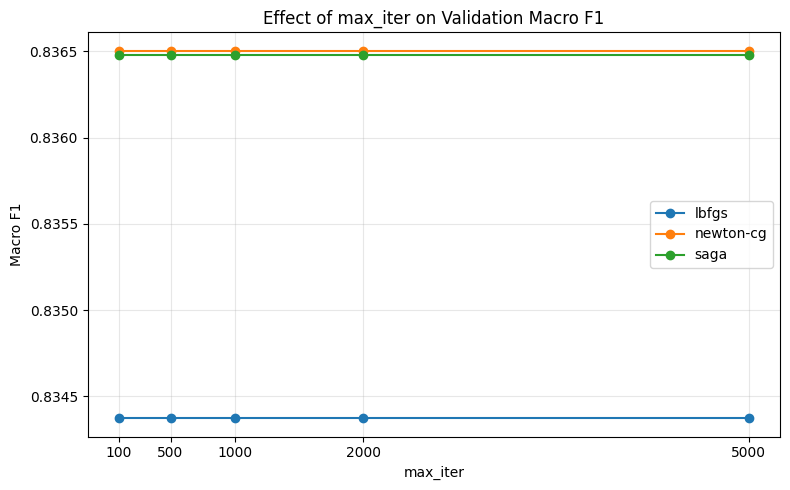

In [26]:
# Plot Macro F1 against max_iter

plt.figure(figsize=(8, 5))

for solver in solvers:

    solver_data = max_iter_df[
        max_iter_df["Solver"] == solver
    ]

    plt.plot(
        solver_data["max_iter"],
        solver_data["Macro F1"],
        marker="o",
        label=solver
    )

plt.xlabel("max_iter")
plt.ylabel("Macro F1")
plt.title("Effect of max_iter on Validation Macro F1")
plt.xticks(max_iter_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/max_iter_vs_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Best model overall
best_model = lr_results_df.loc[
    lr_results_df["Macro F1"].idxmax()
]

best_solver = best_model["Solver"]
best_C = best_model["C"]

print("Best Solver:", best_solver)
print("Best C:", best_C)

Best Solver: newton-cg
Best C: 10.0


In [28]:


best_model_max_iter = (
    lr_results_df[
        (lr_results_df["Solver"] == best_solver) &
        (lr_results_df["C"] == best_C)
    ]
    .sort_values("max_iter")
)

best_model_max_iter[
    [
        "Solver",
        "C",
        "max_iter",
        "Accuracy",
        "Macro F1",
        "Risky Recall",
        "Risky F1",
        "Actual Iterations"
    ]
]

,Solver,C,max_iter,Accuracy,Macro F1,Risky Recall,Risky F1,Actual Iterations
40,newton-cg,10.0,100,0.842667,0.836503,0.823194,0.830297,6
41,newton-cg,10.0,500,0.842667,0.836503,0.823194,0.830297,6
42,newton-cg,10.0,1000,0.842667,0.836503,0.823194,0.830297,6
43,newton-cg,10.0,2000,0.842667,0.836503,0.823194,0.830297,6
44,newton-cg,10.0,5000,0.842667,0.836503,0.823194,0.830297,6


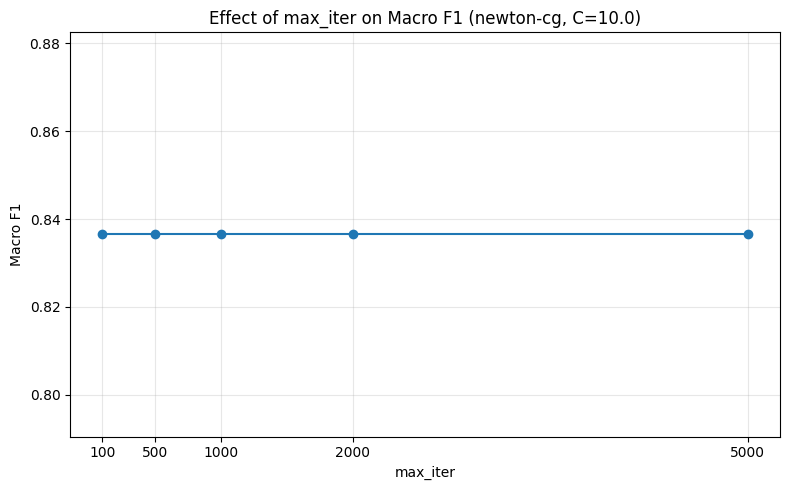

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_model_max_iter["max_iter"],
    best_model_max_iter["Macro F1"],
    marker="o"
)

plt.xlabel("max_iter")
plt.ylabel("Macro F1")
plt.title(
    f"Effect of max_iter on Macro F1 "
    f"({best_solver}, C={best_C})"
)

plt.xticks(max_iter_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [30]:
best_model = lr_results_df.loc[
    lr_results_df["Macro F1"].idxmax()
]

best_solver = best_model["Solver"]
best_C = best_model["C"]

best_model_iterations = (
    lr_results_df[
        (lr_results_df["Solver"] == best_solver) &
        (lr_results_df["C"] == best_C)
    ]
    .sort_values("Actual Iterations")
)

best_model_iterations[
    [
        "max_iter",
        "Actual Iterations",
        "Macro F1",
        "Accuracy",
        "Risky Recall",
        "Risky F1"
    ]
]

,max_iter,Actual Iterations,Macro F1,Accuracy,Risky Recall,Risky F1
40,100,6,0.836503,0.842667,0.823194,0.830297
41,500,6,0.836503,0.842667,0.823194,0.830297
42,1000,6,0.836503,0.842667,0.823194,0.830297
43,2000,6,0.836503,0.842667,0.823194,0.830297
44,5000,6,0.836503,0.842667,0.823194,0.830297


In [38]:
# Finer max_iter values to study convergence

max_iter_values_detailed = [
    1, 2, 3, 4, 5,10, 20, 30, 40, 50,
    75
]

In [39]:
best_solver = solver_summary.iloc[0]["Solver"]
best_C = solver_summary.iloc[0]["C"]

max_iter_detailed_results = []

for max_iter in max_iter_values_detailed:

    model = LogisticRegression(
        solver=best_solver,
        C=best_C,
        max_iter=max_iter,
        random_state=42
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_tfidf,
        y_train
    )

    training_time = time.perf_counter() - start_time

    y_val_pred = model.predict(
        X_val_tfidf
    )

    max_iter_detailed_results.append({
        "max_iter": max_iter,
        "Actual Iterations": model.n_iter_[0],
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Macro F1": f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        ),
        "Risky Recall": recall_score(
            y_val,
            y_val_pred,
            labels=["Risky"],
            average=None,
            zero_division=0
        )[0],
        "Risky F1": f1_score(
            y_val,
            y_val_pred,
            labels=["Risky"],
            average=None,
            zero_division=0
        )[0],
        "Training Time (sec)": training_time
    })

max_iter_detailed_df = pd.DataFrame(
    max_iter_detailed_results
)

max_iter_detailed_df

C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.5308346490110055. Increase the number of iterations.
  warnings.warn(
C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.3140870438730909. Increase the number of iterations.
  warnings.warn(
C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.21734576625493163. Increase the number of iterations.
  warnings.warn(
C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.19999650337132485. Increase the number of iterations.
  warnings.warn(
C:\Users\Jahnavi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\optimize.py:319:

,max_iter,Actual Iterations,Accuracy,Macro F1,Risky Recall,Risky F1,Training Time (sec)
0,1,1,0.792296,0.782807,0.808935,0.776460,0.082159
1,2,2,0.840593,0.833522,0.820342,0.826628,0.159030
2,3,3,0.836444,0.829544,0.813688,0.819531,0.233498
3,4,4,0.847407,0.841831,0.824144,0.833654,0.342520
4,5,5,0.841778,0.835597,0.823194,0.828708,0.438019
5,10,6,0.842667,0.836503,0.823194,0.830297,0.581473
6,20,6,0.842667,0.836503,0.823194,0.830297,0.591284
7,30,6,0.842667,0.836503,0.823194,0.830297,0.604097
8,40,6,0.842667,0.836503,0.823194,0.830297,0.596294
9,50,6,0.842667,0.836503,0.823194,0.830297,0.605646


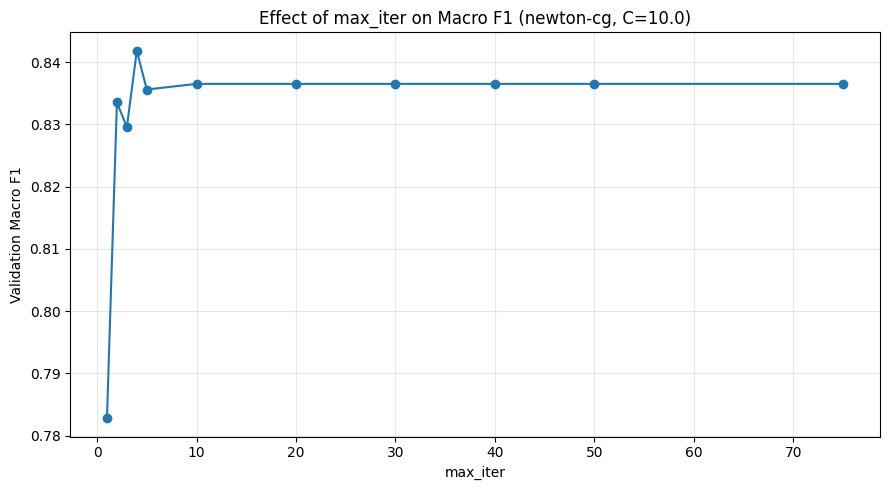

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(
    max_iter_detailed_df["max_iter"],
    max_iter_detailed_df["Macro F1"],
    marker="o"
)

plt.xlabel("max_iter")
plt.ylabel("Validation Macro F1")

plt.title(
    f"Effect of max_iter on Macro F1 "
    f"({best_solver}, C={best_C})"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [42]:
best_solver_models = {}

for _, row in solver_summary.iterrows():

    solver = row["Solver"]
    C = row["C"]
    max_iter = int(row["max_iter"])

    model = LogisticRegression(
        solver=solver,
        C=C,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    y_val_pred = model.predict(X_val_tfidf)

    best_solver_models[solver] = {
        "model": model,
        "predictions": y_val_pred,
        "C": C,
        "max_iter": max_iter
    }

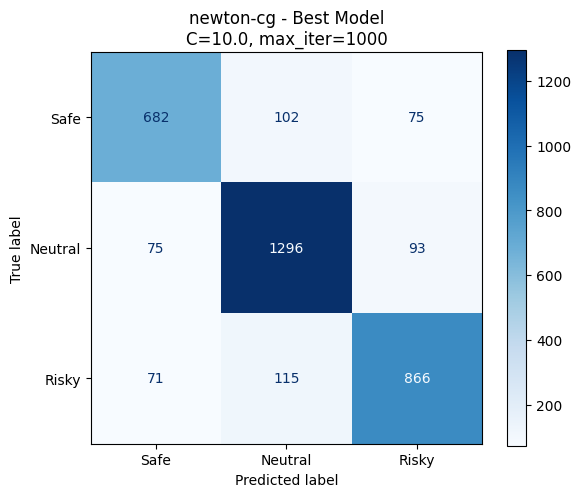

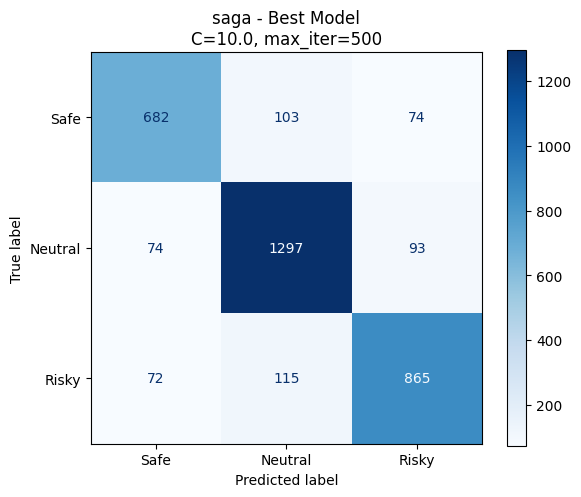

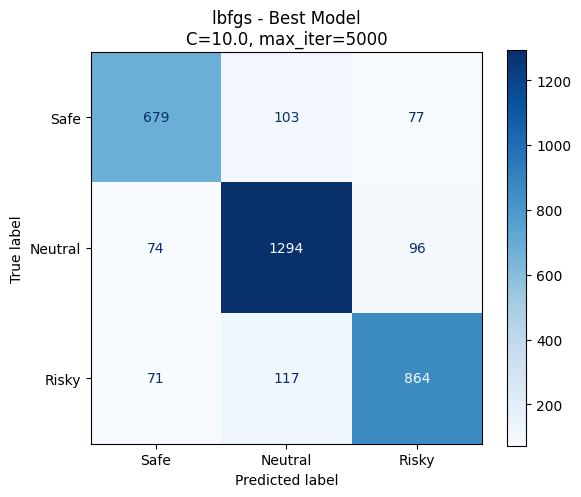

In [49]:
import os
for solver in solver_summary["Solver"]:

    y_val_pred = best_solver_models[solver]["predictions"]

    cm = confusion_matrix(
        y_val,
        y_val_pred,
        labels=["Safe", "Neutral", "Risky"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Safe", "Neutral", "Risky"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    disp.plot(
        ax=ax,
        values_format="d",cmap=plt.cm.Blues
    )

    row = solver_summary[
        solver_summary["Solver"] == solver
    ].iloc[0]

    ax.set_title(
        f"{solver} - Best Model\n"
        f"C={row['C']}, max_iter={int(row['max_iter'])}"
    )

    plt.tight_layout()

    # Save confusion matrix
    filename = f"confusion_matrix_{solver}.png"

    plt.savefig(
        os.path.join("results", filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

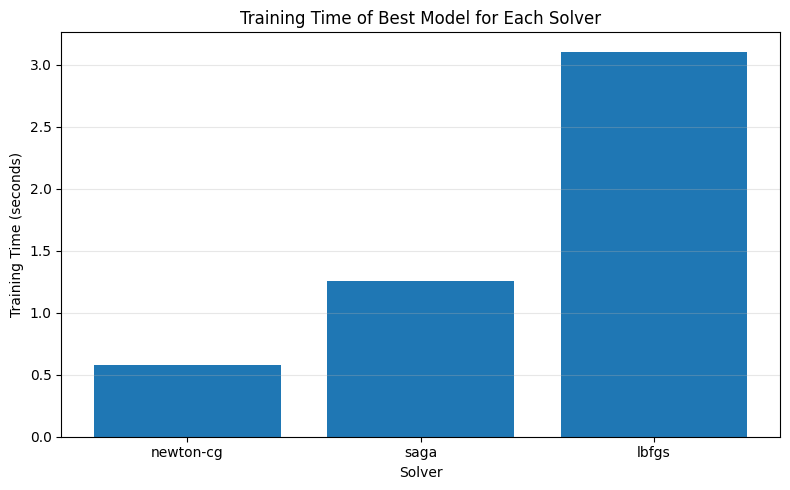

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    solver_summary["Solver"],
    solver_summary["Training Time (sec)"]
)

plt.xlabel("Solver")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time of Best Model for Each Solver")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "results/best_model_training_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
solver_summary.to_csv(
    "results/best_models_all_solvers.csv",
    index=False
)

In [52]:

best_model_result = lr_results_df.loc[
    lr_results_df["Macro F1"].idxmax()
]

best_solver = best_model_result["Solver"]
best_C = best_model_result["C"]
best_max_iter = int(best_model_result["max_iter"])

print("Best Solver:", best_solver)
print("Best C:", best_C)
print("Best max_iter:", best_max_iter)

Best Solver: newton-cg
Best C: 10.0
Best max_iter: 100


In [53]:
best_model = LogisticRegression(
    solver=best_solver,
    C=best_C,
    max_iter=best_max_iter,
    random_state=42
)

best_model.fit(
    X_train_tfidf,
    y_train
)

y_val_pred_best = best_model.predict(
    X_val_tfidf
)

In [54]:
best_model_report = classification_report(
    y_val,
    y_val_pred_best,
    labels=["Safe", "Neutral", "Risky"],
    output_dict=True,
    zero_division=0
)

best_model_per_class = pd.DataFrame(
    best_model_report
).transpose()

best_model_per_class = best_model_per_class.loc[
    ["Safe", "Neutral", "Risky"],
    ["precision", "recall", "f1-score", "support"]
]

best_model_per_class

,precision,recall,f1-score,support
Safe,0.823671,0.793946,0.808536,859.0
Neutral,0.856576,0.885246,0.870675,1464.0
Risky,0.837524,0.823194,0.830297,1052.0


In [55]:
best_model_per_class.to_csv(
    "results/best_model_per_class_results.csv"
)